In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# AC OWNERS FILTERING
print("\n🎯 FILTERING TO AC OWNERS")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get customers with AC
has_ac = df_quotes.groupby('numero_compte')['famille_equipement_produit'].apply(
    lambda x: 'Climatisation' in x.values
)

ac_owner_ids = has_ac[has_ac].index.tolist()

# Filter data
df_quotes_ac = df_quotes[df_quotes['numero_compte'].isin(ac_owner_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"AC owners: {len(ac_owner_ids):,}")
print(f"Quotes: {len(df_quotes_ac):,}")

# Save to file
df_quotes_ac.to_csv('cleaned_quote_data_ac.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_ac.csv")


🎯 FILTERING TO AC OWNERS
Original customers: 25,716
AC owners: 5,189
Quotes: 8,462

✅ Saved to cleaned_quote_data_ac.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_ac.csv')


📊 Original quote data: 8,462 quotes from 5,189 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 5,189, Quotes: 8,045
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 5,189 customers | 32.9% converters
⏱️  Execution time: 2.2 seconds
✅ SUCCESS! Achieved ≤ 3s target
CREATING FIRST CONVERSION PREDICTION FEATURES (LEAKAGE-FREE)
  Total customers: 5,189
⚡ Processing customers with corrected first-conversion logic...
  Processed 0/5,189 customers
  Processed 5,000/5,189 customers
✅ First-conversion features calculation complete

🔍 VALIDATION REPORT:
   Total customers: 5,189
   First converters: 1,709 (32.9%)
   Never converters: 3,480

📊 Distribution check:
   Converters with 0 historical quotes: 1,294
   Non-converters with 0 historical quotes: 2,247
   Avg historical quotes - Converters: 0.4
   Avg hi

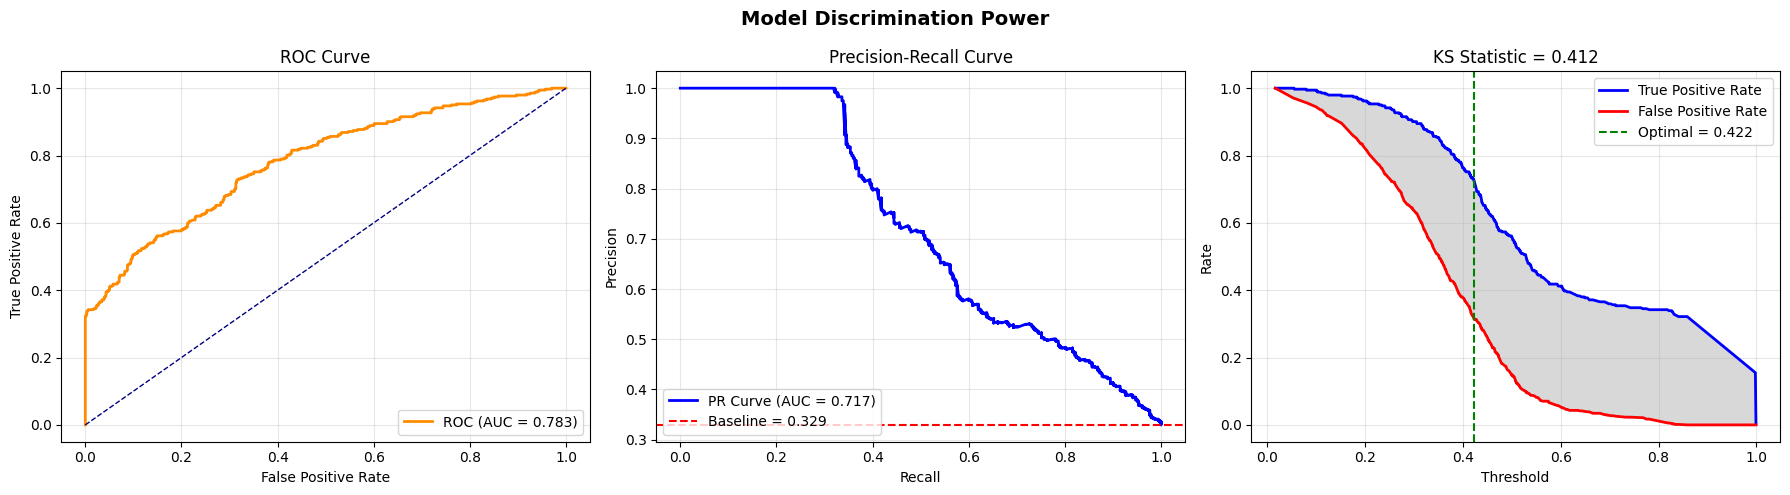

• ROC-AUC: 0.7827
• PR-AUC: 0.7174
• KS Statistic: 0.412 (GOOD discrimination)
• Optimal Threshold: 0.422

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.998
Decile 10 mean prob: 0.107


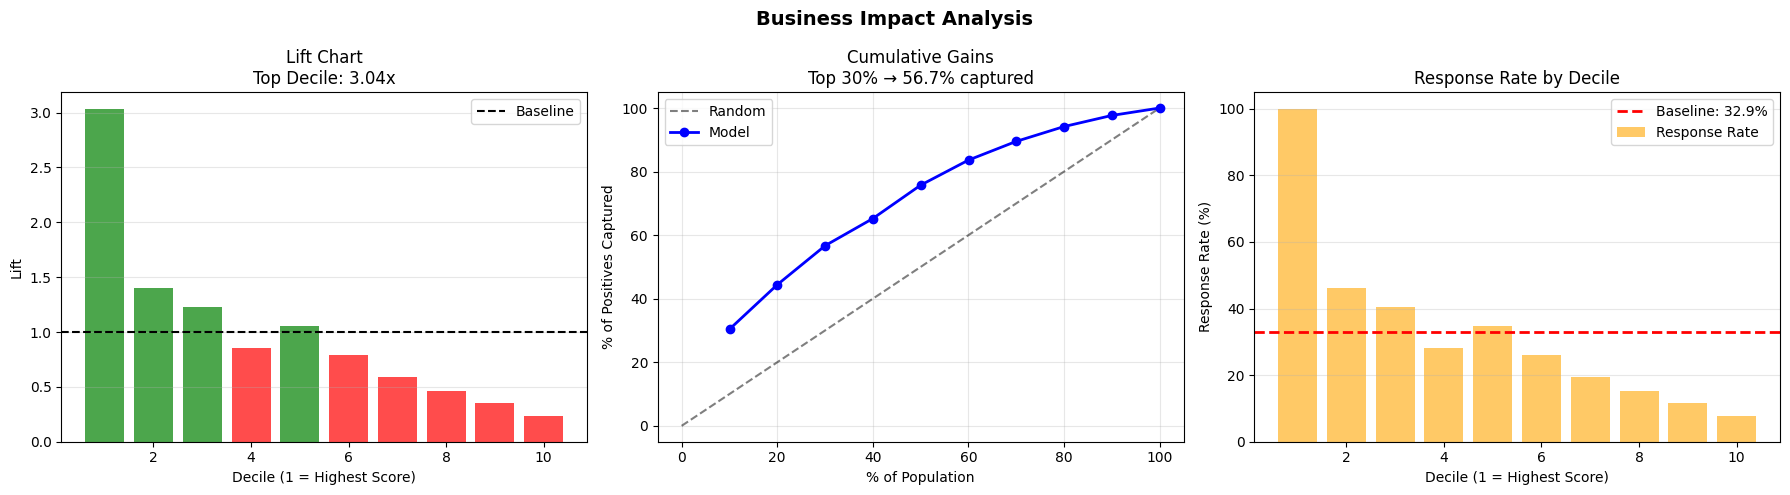

• Top Decile Lift: 0.23x
• Top 30% captures: 56.7% of positives
• Baseline response rate: 32.9%
• Top decile response: 100.0%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


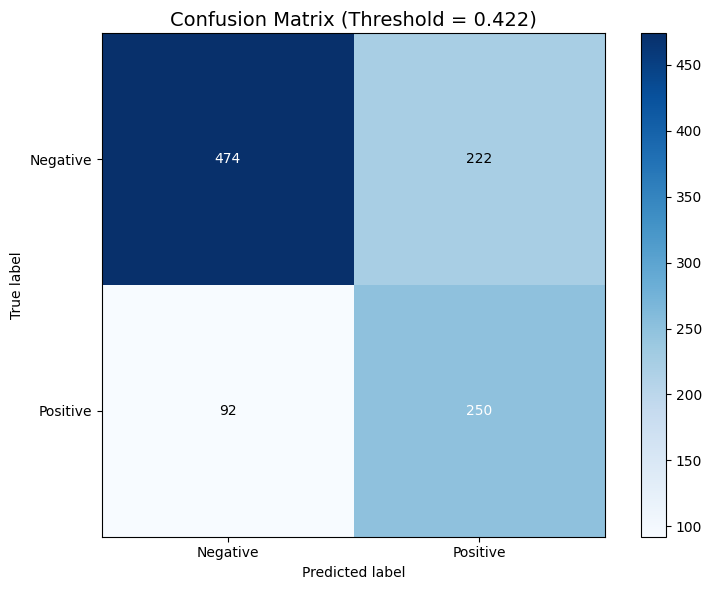

At threshold 0.422:
• Accuracy: 0.697
• Precision: 0.530
• Recall: 0.731
• F1-Score: 0.614
• True Positives: 250
• False Positives: 222
• True Negatives: 474
• False Negatives: 92

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.412 (GOOD discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.23x better than random
   Coverage: Top 30% → 56.7% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.7827 (Excellent if >0.8)
   PR-AUC: 0.7174 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.422
   Precision at threshold: 0.530
   Recall at threshold: 0.731

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                         feature  importance
176      quote_consistency_score    0.133565
205         complexity_per_quote    0.049279
165             is_quick_decider    0.025492
49         brand_diversity_index    0.020555
36           model_variety_score    0.017005
58                min_complexity    0.016579
248                  value_score    0.01

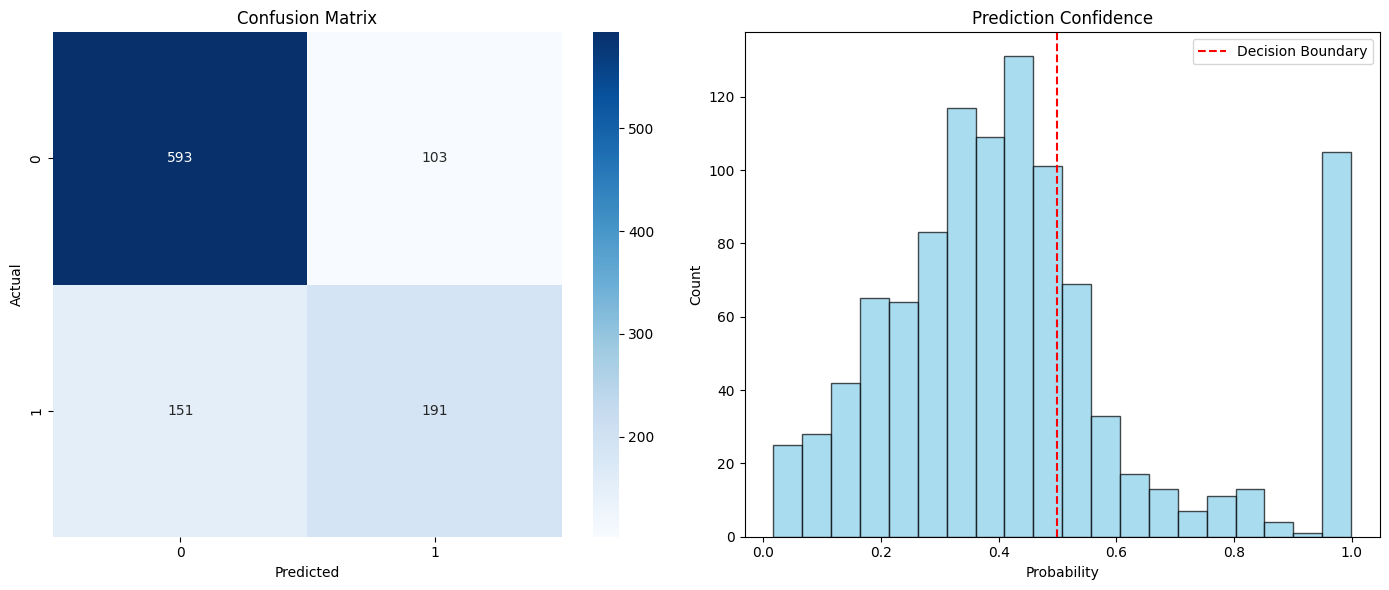

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])